# EXPLORATORY DATA ANALYSIS

## Exploratory Data Analysis

The purpose of this exploratory data analysis (EDA) is to better understand the SEER lung and bronchus cancer dataset before beginning the data preprocessing and modeling stages. The dataset contains demographic, diagnostic, tumor, treatment, and survival-related information for patients diagnosed with lung and bronchus cancer. Before developing a neural network model, it is important to understand the structure and quality of the available data, including the distributions of individual features, the presence of missing or unknown values, and relationships between variables.

During the analysis, I will examine both numerical and categorical features to identify patterns that may be relevant to patient survival. I will also investigate relationships between features, particularly whether characteristics such as age, tumor size, lymph node involvement, diagnosis year, cancer characteristics, and treatment are associated with differences in survival outcomes. In addition, the EDA will help identify potential data-quality issues, unusual values, highly imbalanced categories, and variables that may require transformation or exclusion during preprocessing.

The findings from this analysis will be used to guide decisions in the next stage of the project, including which variables should be included in the model, and which transformations may be appropriate before training the neural network.


<a id="import"></a>
## Import and View the Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset and see column names and their types.

df = pd.read_csv('../Data/Lung_and_Bronchus.csv')

print(df.info())
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 579970 entries, 0 to 579969
Data columns (total 20 columns):
 #   Column                                                  Non-Null Count   Dtype
---  ------                                                  --------------   -----
 0   Sex                                                     579970 non-null  str  
 1   Site recode ICD-O-3/WHO 2008                            579970 non-null  str  
 2   Behavior code ICD-O-3                                   579970 non-null  str  
 3   Histologic Type ICD-O-3                                 579970 non-null  int64
 4   RX Summ--Surg Prim Site (1998+)                         579970 non-null  int64
 5   Radiation recode                                        579970 non-null  str  
 6   Chemotherapy recode (yes, no/unk)                       579970 non-null  str  
 7   RX Summ--Scope Reg LN Sur (2003+)                       184846 non-null  str  
 8   Time from diagnosis to treatment in days recode        

- Drop the below columns as they don't contain any predictive value

In [19]:
df.drop(columns=['Site recode ICD-O-3/WHO 2008', 'Behavior code ICD-O-3'])

,Sex,Histologic Type ICD-O-3,RX Summ--Surg Prim Site (1998+),Radiation recode,"Chemotherapy recode (yes, no/unk)",RX Summ--Scope Reg LN Sur (2003+),Time from diagnosis to treatment in days recode,Survival months,Visceral and Parietal Pleural Invasion Recode (2010+),SEER Combined Mets at DX-lung (2010+),SEER cause-specific death classification,Age recode with <1 year olds and 90+,Tumor Size Over Time Recode (1988+),Regional nodes examined (1988+),Regional nodes positive (1988+),Separate Tumor Nodules Ipsilateral Lung Recode (2010+),"Race recode (W, B, AI, API)",Year of diagnosis
0,Male,8140,33,None/Unknown,Yes,4 or more regional lymph nodes removed,058,0047,PL1 or PL2; Invasion of visceral pleura presen...,No,Alive or dead of other cause,65-69 years,070,16,9,None; No intrapulmonary mets; Foci in situ/min...,White,2018
1,Female,8010,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0003,Not documented; No resection of primary; Not a...,No,Alive or dead of other cause,75-79 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,White,2011
2,Female,8140,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0029,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,030,0,98,None; No intrapulmonary mets; Foci in situ/min...,Black,2010
3,Female,8140,0,Beam radiation,Yes,NaN,019,0027,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,109,0,98,Separate nodules of same hist type in ipsilate...,White,2016
4,Female,8041,0,None/Unknown,No/Unknown,NaN,Unable to calculate,0000,Not documented; No resection of primary; Not a...,No,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,0,98,Not documented; Primary tumor is in situ; Not ...,Black,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579965,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,Black,2021
579966,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),80-84 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579967,Female,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),85-89 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021
579968,Male,8000,99,None/Unknown,No/Unknown,Unknown or not applicable,Unable to calculate,Unknown,Not documented; No resection of primary; Not a...,Unknown,Dead (attributable to this cancer dx),65-69 years,Unknown or size unreasonable (includes any tum...,99,99,Not documented; Primary tumor is in situ; Not ...,White,2021


## Handle Missing Values
In the below cell, we see that the 2 features *RX Summ--Scope Reg LN Sur (2003+)* and *SEER Combined Mets at DX-lung (2010+)* both contain 'NaN' values. These 'NaN' values are substitutions for blank cells/entries. It's important to consider that these blank values are separate from the entries representing 'unknown' or 'N/A', and thus I feel that it would be incorrect to simply group these values together. For the former feature mentioned, I have elected to remove the feature entirely, as over 68% of entries are blank, and this combined with a lack of documentation on why entries are left blank concerns me with regards to its reliability. For *SEER Combined Mets at DX-lung (2010+)*, I decided to remove the data entries containing those blank entries, as only a very small portion of entries have that blank entry.

In [20]:
## Handle missing values in each category

#see unqiue values at column with missing values
print(df['RX Summ--Scope Reg LN Sur (2003+)'].unique())
print(df['SEER Combined Mets at DX-lung (2010+)'].unique())

#Handle missing values
df = df.dropna(subset=['SEER Combined Mets at DX-lung (2010+)'])
df = df.drop(columns='RX Summ--Scope Reg LN Sur (2003+)')

<StringArray>
[                    '4 or more regional lymph nodes removed',
                                                          nan,
           'Biopsy or aspiration of regional lymph node, NOS',
                        '1 to 3 regional lymph nodes removed',
                                  'Unknown or not applicable',
             'Number of regional lymph nodes removed unknown',
                                 'Sentinel lymph node biopsy',
 'Sentinel node biopsy and lym nd removed same/unstated time',
    'Sentinel node biopsy and lym nd removed different times']
Length: 9, dtype: str
<StringArray>
['No', 'Yes', 'Unknown', nan]
Length: 4, dtype: str


## Data Transformation
- Convert the below features from string values to number values (Int64). This makes them easier to work with, and prepares them for future transformation/preprocessing. Before handling unknown/missing values, I will visualize the variables. Doing so will allow to better understand the distribution of known values for each feature before deciding on how to impute them.

- For the age groups, I elect to use the midpoint of each age group to preserve the distance between each age group.

In [21]:
print(df.iloc[:, [7, 8]].head(10))

col = 'Time from diagnosis to treatment in days recode'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

df['Survival months'] = pd.to_numeric(df['Survival months'], errors="coerce").astype("Int64")

col = 'Tumor Size Over Time Recode (1988+)'
df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

  Time from diagnosis to treatment in days recode Survival months
0                                             058            0047
1                             Unable to calculate            0003
2                             Unable to calculate            0029
3                                             019            0027
4                             Unable to calculate            0000
5                                             039            0052
6                                             045            0012
7                                             023            0047
8                                             148            0016
9                             Unable to calculate            0000


In [22]:
print(df.iloc[:, 12].unique())

def age_to_midpoint(age):
    lower = int(age[:2])

    if lower > 0:
        return lower + 2
    return lower

    
col = 'Age recode with <1 year olds and 90+'

df[col] = df[col].apply(age_to_midpoint)

df[col].unique()


<StringArray>
['65-69 years', '75-79 years', '80-84 years', '85-89 years', '55-59 years',
 '60-64 years',   '90+ years', '70-74 years', '50-54 years', '45-49 years',
 '40-44 years', '35-39 years', '30-34 years', '25-29 years', '20-24 years',
 '15-19 years', '10-14 years',    '00 years', '05-09 years', '01-04 years']
Length: 20, dtype: str


array([67, 77, 82, 87, 57, 62, 92, 72, 52, 47, 42, 37, 32, 27, 22, 17, 12,
        0,  7,  3])

## Univariate Analysis

- Visualize the features individually to better understand which values are most common/rare, skewness, etc.

In [23]:
categorical = [
    'Sex',
    'Age recode with <1 year olds and 90+',
    'Histologic Type ICD-O-3',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)',
    'Visceral and Parietal Pleural Invasion Recode (2010+)',
    'SEER Combined Mets at DX-lung (2010+)',
    'SEER cause-specific death classification',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)',
    'Race recode (W, B, AI, API)'
]

categorical_labels = {
    'Sex': 'Sex',
    'Age recode with <1 year olds and 90+': 'Age',
    'Histologic Type ICD-O-3': 'Histologic Type',
    'RX Summ--Surg Prim Site (1998+)': 'Surgery site',
    'Radiation recode': 'Radiation',
    'Chemotherapy recode (yes, no/unk)': 'Chemotherapy',
    'Visceral and Parietal Pleural Invasion Recode (2010+)': 'Pleural Invasion',
    'SEER Combined Mets at DX-lung (2010+)': 'Mets at Diagnosis',
    'SEER cause-specific death classification': 'Cause-Specific Death',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)': 'Separate Tumor Nodules',
    'Race recode (W, B, AI, API)': 'Race'
}

numerical = [
    'Time from diagnosis to treatment in days recode',
    'Survival months',
    'Tumor Size Over Time Recode (1988+)',
    'Regional nodes examined (1988+)',
    'Regional nodes positive (1988+)',
    'Year of diagnosis'
]

numerical_labels = {
    'Time from diagnosis to treatment in days recode': 'Time From Diagnosis to Treatment',
    'Year of diagnosis': 'Diagnosis Year',
    'Tumor Size Over Time Recode (1988+)': 'Tumor Size',
    'Regional nodes examined (1988+)': 'Nodes Examined',
    'Regional nodes positive (1988+)': 'Nodes Positive',
    'Survival months': 'Survival Months'
}

### Numerical Feature Exploration

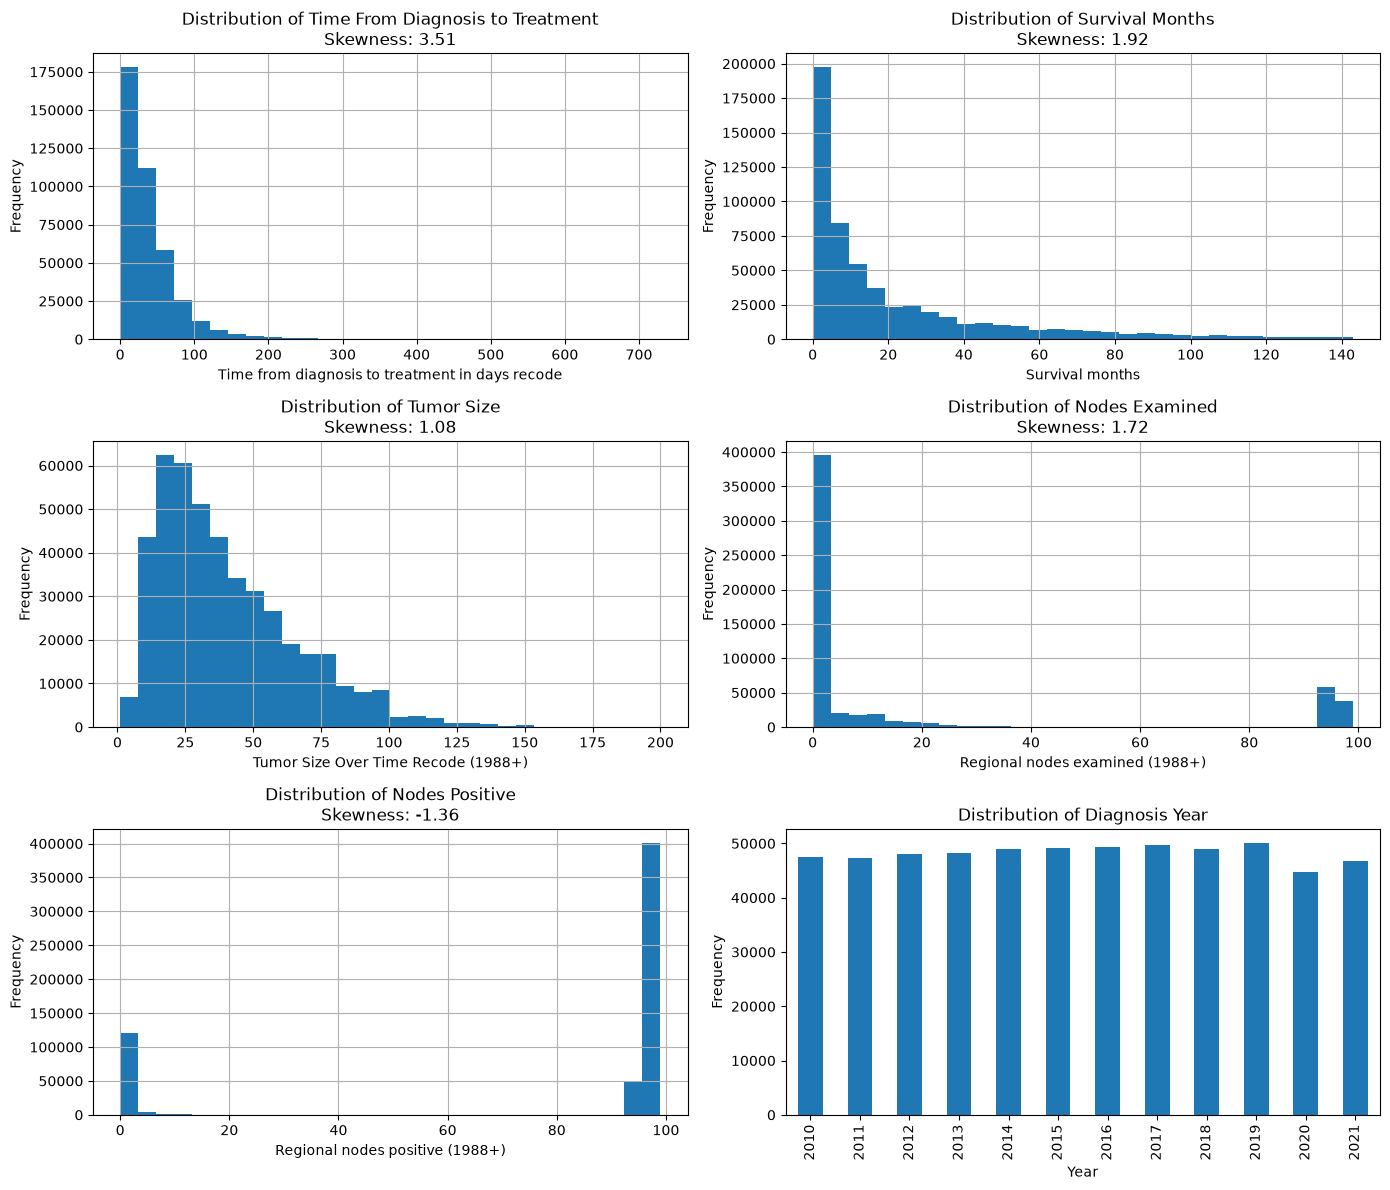

In [24]:


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerical):

    if col == 'Year of diagnosis':
        df[col].value_counts().sort_index().plot(
            kind='bar',
            ax=ax
        )
        ax.set_xlabel('Year')
        ax.set_title(f'Distribution of {numerical_labels[col]}')

    else:
        df[col].hist(
            bins=30,
            ax=ax
        )
        ax.set_xlabel(col)

        skew = df[col].skew()
        ax.set_title(f'Distribution of {numerical_labels[col]}\nSkewness: {skew:.2f}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation of numerical features

- For the charts representing continuous features (Time from diagnosis to treatment, survival months, tumor size), I will use an automated power transformer to normalize them (after creating training/test split).
- For regional nodes examined/positive, more probing will be needed to determine the cause for their distributions. My initial suspicion is that many of the entries are that there were no nodes examined. As per the ['SEER Research Data Record Description'](https://seer.cancer.gov/data-software/documentation/seerstat/nov2025/TextData.FileDescription-nov2025.pdf), for *regional nodes examined (1988+)*, 0 represents 'no nodes were examined.' For *regional nodes positive (1988+)*, 98 represents the same. These are the corresponding values that are dominating their respective graphs above.

In [25]:
df[['Regional nodes examined (1988+)', 'Regional nodes positive (1988+)']].value_counts()


Regional nodes examined (1988+)  Regional nodes positive (1988+)
0                                98                                 370738
95                               95                                  49761
99                               99                                  28610
95                               0                                    8741
1                                1                                    5587
                                                                     ...  
62                               7                                       1
85                               0                                       1
36                               33                                      1
41                               22                                      1
30                               22                                      1
Name: count, Length: 1032, dtype: int64

To handle the above values, I will create 2 new features to represent values greater than 90 in each of the above features. This is because only values between 0-89 represent exact counts of nodes that were examined/positive. The other values represent special categories, and I feel that these can still have predictive value. For the known values (0-89), I will visualize them alone excluding the special values to determine the skewness, and then impute compatible special values accordingly.

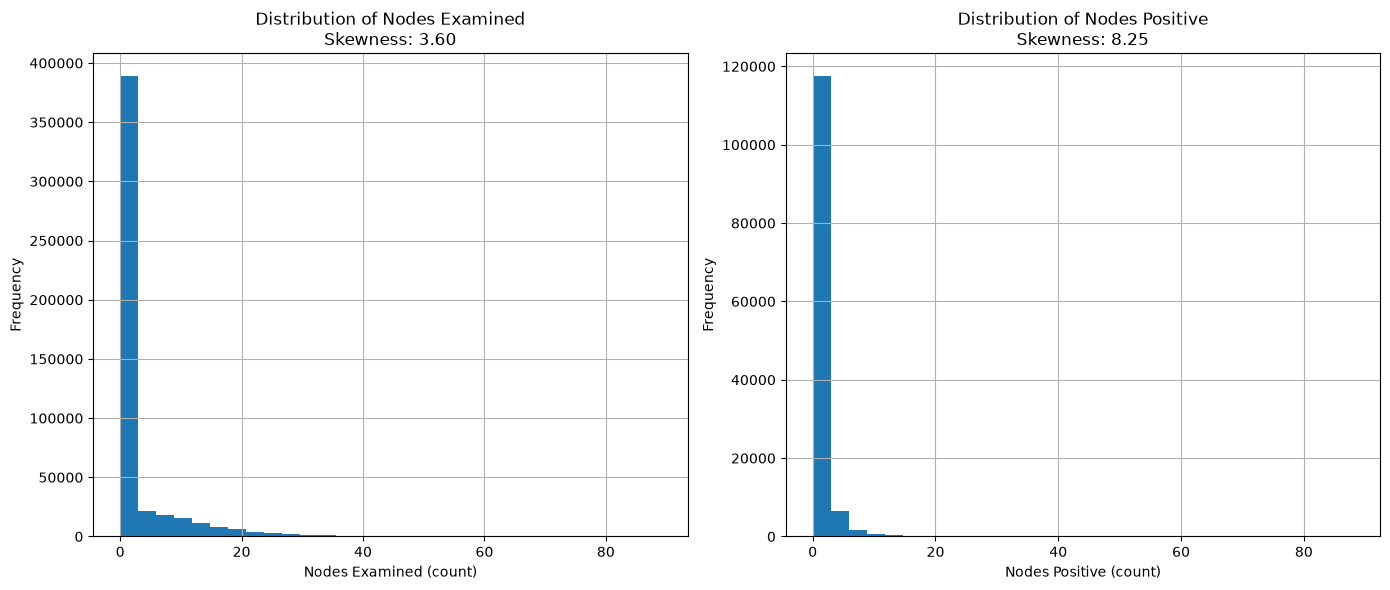

In [26]:
# create new columns
# remove values from original columns so they are N/A
# visualize original columns
# Adjust based on skewness
# Impute N/A values in original categories


new_col_pos = 'Regional nodes positive treatment'
col_pos = 'Regional nodes positive (1988+)'

df[new_col_pos] = df[col_pos].where(df[col_pos] >= 90)
df[col_pos] = df[col_pos].where(df[col_pos] <= 89)


new_col_ex = 'Regional nodes examined treatment'
col_ex = 'Regional nodes examined (1988+)'

df[new_col_ex] = df[col_ex].where(df[col_ex] >= 90)
df[col_ex] = df[col_ex].where(df[col_ex] <= 89)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

regional_nodes_cols = [col_ex, col_pos]

for ax, col in zip(axes, regional_nodes_cols):
    df[col].hist(
        bins=30,
        ax=ax
    )
    ax.set_xlabel(f'{numerical_labels[col]} (count)')

    skew = df[col].skew()
    ax.set_title(f'Distribution of {numerical_labels[col]}\nSkewness: {skew:.2f}')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

As seen in the above charts, both regional node categories are heavily rightly skewed in the context of cases with an exact amount of regional nodes examined. A power transform will need to be done after splitting the data.

### Categorical Feature Exploration

In [27]:
#visualize categorical features

for col in categorical:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100

    result = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(2)
    })

    print(f'\n--- {categorical_labels[col]} ---')
    print(result)


--- Sex ---
         Count  Percentage
Sex                       
Male    298056       51.46
Female  281126       48.54

--- Age ---
                                       Count  Percentage
Age recode with <1 year olds and 90+                    
72                                    102400       17.68
67                                     96371       16.64
77                                     90757       15.67
62                                     74249       12.82
82                                     67051       11.58
57                                     50161        8.66
87                                     38114        6.58
52                                     25844        4.46
92                                     16857        2.91
47                                     10394        1.79
42                                      3865        0.67
37                                      1636        0.28
32                                       768        0.13
27         

#### Interpretation of Categorical Features

- Something that immediately jumps out to me is that the most prominent age groups in the dataset are all older individuals (50+ years old). This will be important to keep in mind as older individuals are surely at higher risk of passing away sooner due to complications relating to their cancer diagnosis.

- Histoligic code 8140 refers to 'Adenocarcinoma', which is a very frequent from of Lung cancer. Histologic code 8070 refers to 'Squamous cell carcinoma'. Per the SEER ['Types of Lung Histologies'](https://training.seer.cancer.gov/lung/lung-histologies.html), this is more strongly linked with smoking. Histologic code 8041 refers to 'Small cell carcinoma', and is a rapid-growing cancer, also spreading quickly to lymph nodes and other organs, per the same source 

- Over 75% of records in the dataset did not have surgery. This initially led me to believe that surgery may have been seen as less useful in most of these cases and that chemotherapy/radiation was opted for instead. However, for both treatment methods, around 61% have the value 'No/Unknown', so it is difficult to say for sure how many of the patients had chemotherapy/radiation.

- Visceral and Parietel Pleural Invasion has a large majority of its records as 'Not documented...'.

- ~60% of records have the outcome of the patient having passed away due to this cancer diagnosis.

- Over 80% of records come from patients that identify as White. I was initially unsure about including Race in the dataset, and after seeing this distribution I fear the model may learn patterns that are biased towards the dominant category, if such patterns exist.

## Bivariate Analysis
### Numerical vs Numerical

- Pearson's r shows linear correlation, Spearman's p shows monotonic non-linear correlation



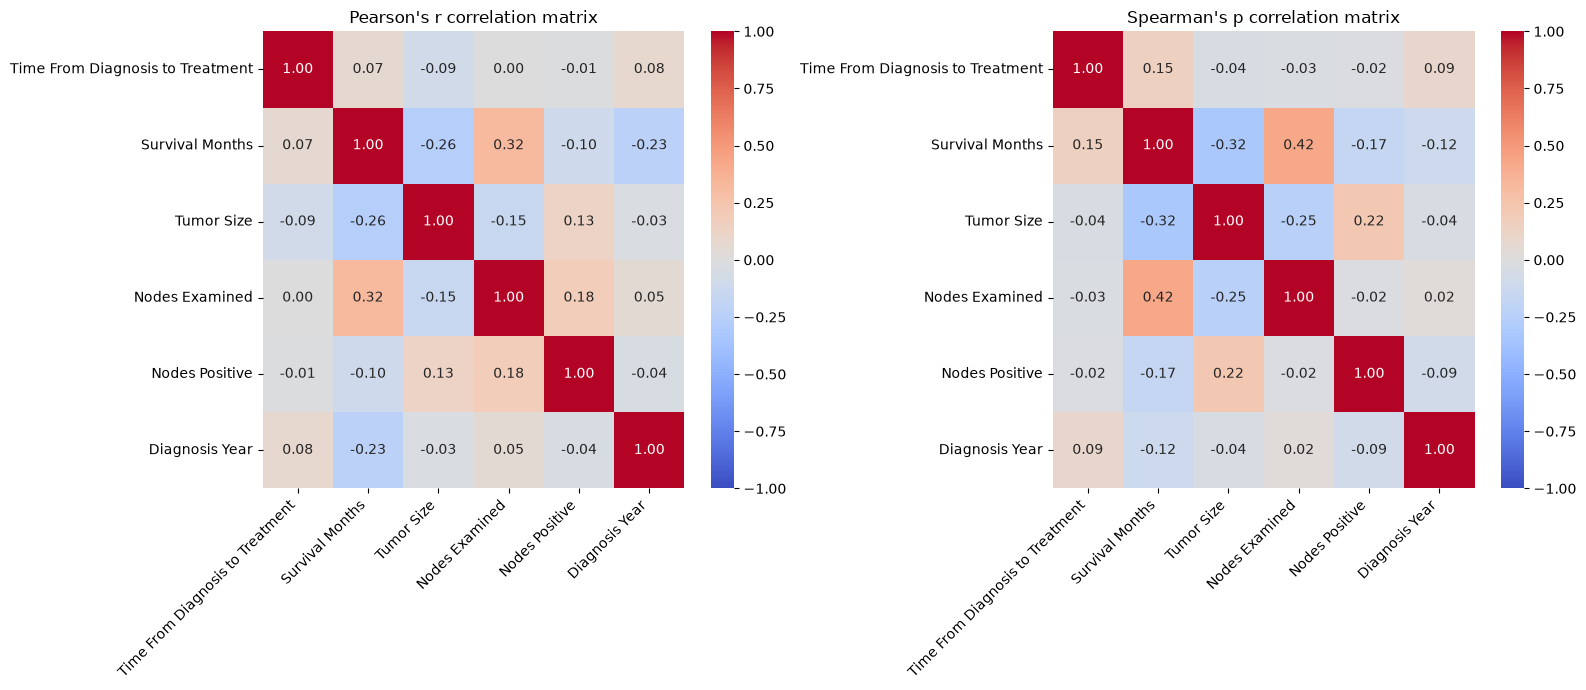

In [28]:
pearson = df[numerical].corr(method='pearson')
spearman = df[numerical].corr(method='spearman')

pearson = pearson.rename(
    index=numerical_labels,
    columns=numerical_labels
)

spearman = spearman.rename(
    index=numerical_labels,
    columns=numerical_labels
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    pearson,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax1
)
ax1.set_title('Pearson\'s r correlation matrix')

sns.heatmap(
    spearman,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax2
)
ax2.set_title("Spearman\'s p correlation matrix")

for ax in (ax1, ax2):
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Using both Pearson's *r* and Spearman's *p*, there doesn't seem to be strong one-to-one correlation between any of the numerical variables. In these charts, I was specifically looking, or hoping for, strongly correlated variables with 'Survival Months'. From the above, it seems that 'Regional Nodes Examined' has a stronger direct correlation than the other numerical variables, but interestingly enough 'Regional Nodes Positive' has a much weaker correlation. I imagine this is due to:
1. 'Regional Nodes Positive' has much fewer values in its numerical column after removing the categorical values (> 90) in comparison to 'Regional Nodes Examined'.
2. The distribution of the trimmed 'Regional Nodes Positive' column has a less diverse distribution compared to 'Regional Nodes Examined'

### Categorical vs Categorical

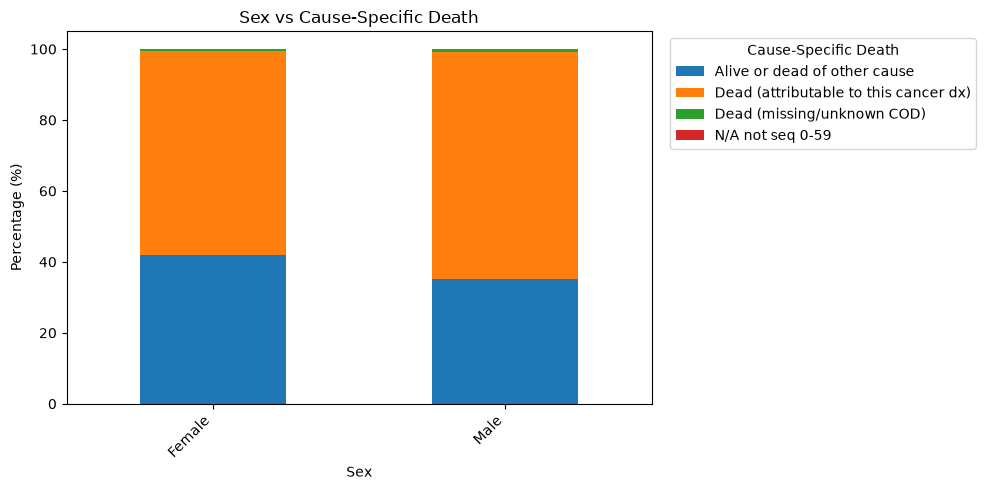

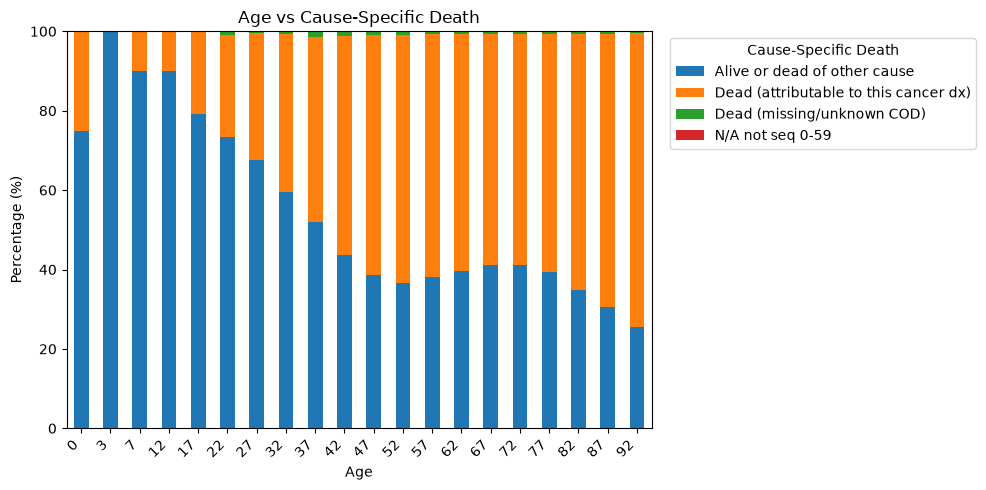

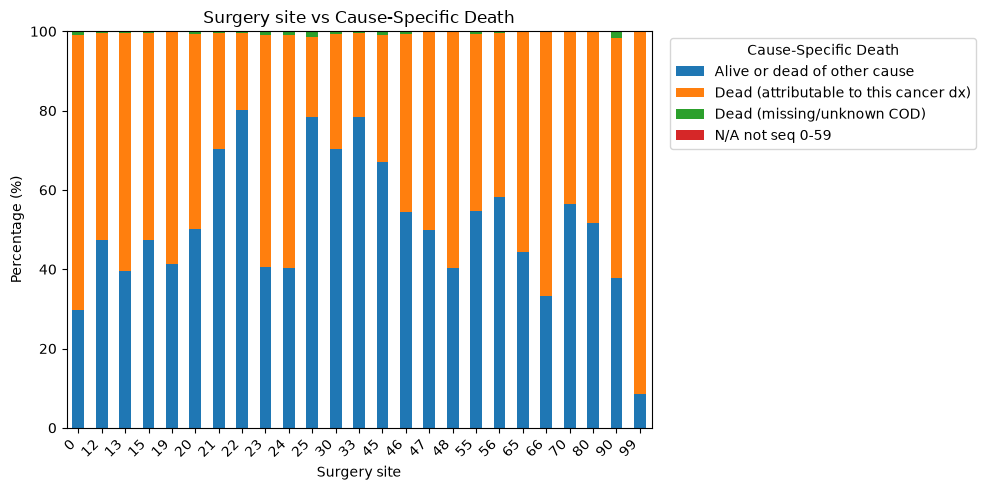

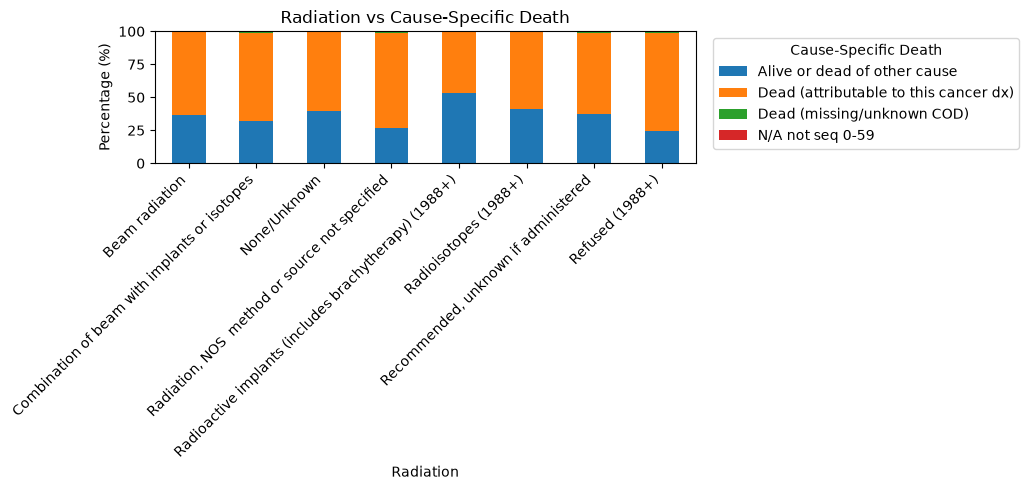

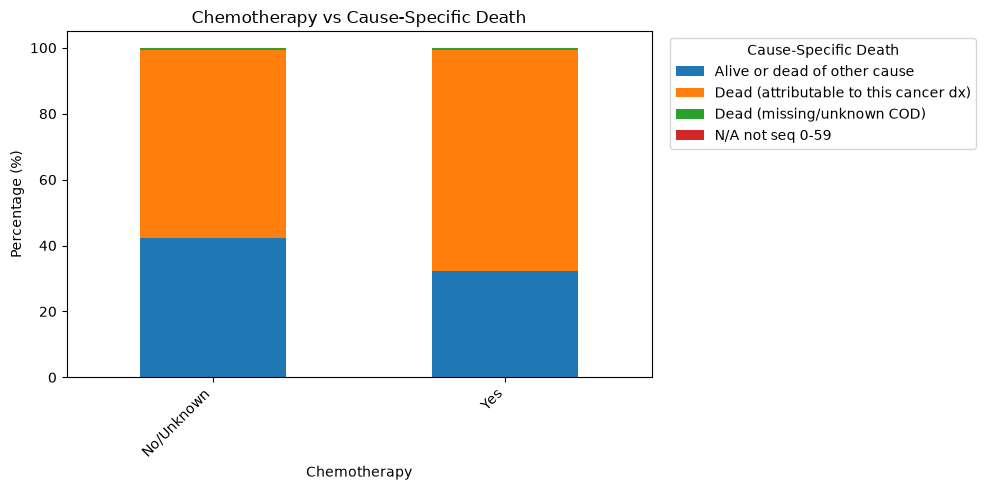

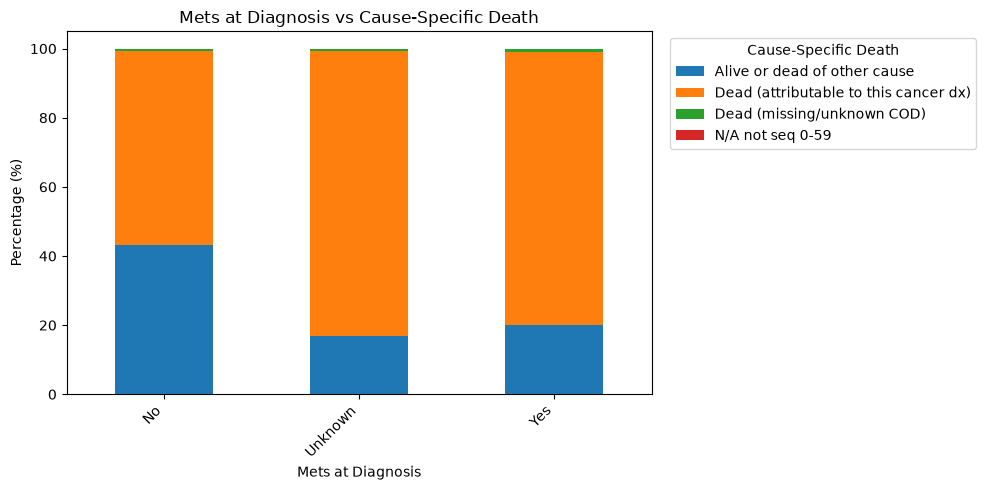

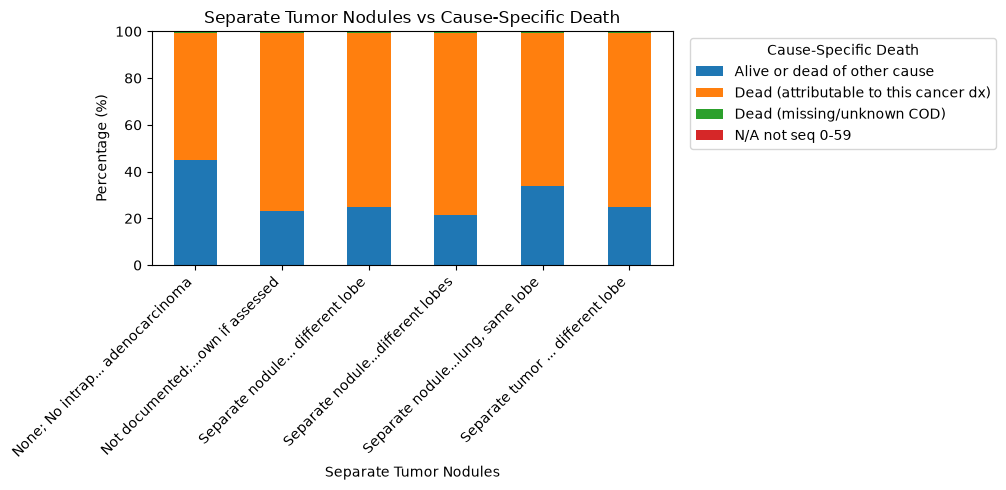

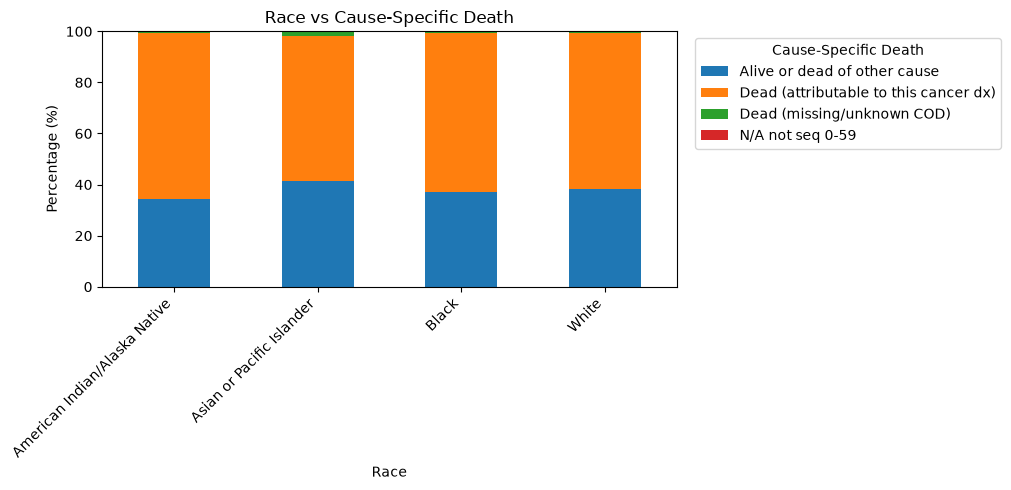

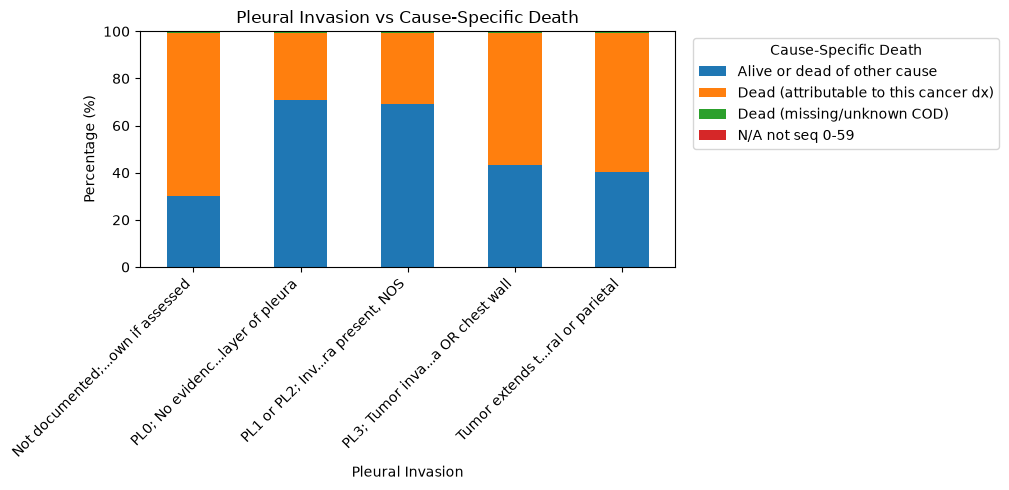

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

target = 'SEER cause-specific death classification'

# Only include these categorical predictors
categorical_plot = [
    'Sex',
    'Age recode with <1 year olds and 90+',
    'RX Summ--Surg Prim Site (1998+)',
    'Radiation recode',
    'Chemotherapy recode (yes, no/unk)',
    'SEER Combined Mets at DX-lung (2010+)',
    'Separate Tumor Nodules Ipsilateral Lung Recode (2010+)',
    'Race recode (W, B, AI, API)',
    'Visceral and Parietal Pleural Invasion Recode (2010+)'
]

for col in categorical_plot:

    # Create percentage table
    ct = pd.crosstab(
        df[col],
        df[target],
        normalize='index'
    ) * 100

    # Shorten long category names specifically for these variables
    if categorical_labels[col] in [
        'Pleural Invasion',
        'Separate Tumor Nodules'
    ]:
        ct.index = ct.index.map(
            lambda x: f'{str(x)[:15]}...{str(x)[-15:]}'
            if len(str(x)) > 30
            else str(x)
        )

    # Plot
    ax = ct.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5)
    )

    ax.set_title(f'{categorical_labels[col]} vs Cause-Specific Death')
    ax.set_xlabel(categorical_labels[col])
    ax.set_ylabel('Percentage (%)')

    ax.legend(
        title='Cause-Specific Death',
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

- Looking at the above, the most prominent pattern that jumps out is that deaths due to this cancer diagnosis increase as the age groups get older, which is expected.
- Patients that don't get surgery seem to die more often than those who do, but 76% of the records are of patients that did not have any surgery. I suspect that this result is less of a pattern, and more so due to their being way more records of people without surgery.
- Success of radiation techniques in relation to deaths varies.
- No distinction in survival rates between races. This alongside my earlier findings leads me to decide to remove the race feature altogether, and focus instead on predicting based on clinical/disease characteristics.

## Conclusion

The exploratory data analysis provided a better understanding of the SEER lung and bronchus cancer dataset, including its feature distributions, data quality, and potential relationships with survival outcomes.

Several data-quality considerations were identified throughout the analysis, such as missing/unknown values, highly skewed features, or numerical features that didn't contain conventional encodings. Some specific preprocessing steps that will have to be taken in the next stage are:
- Remove column representing patient race
- Power transform skewed numerical variables

The analysis also revealed that relationships between individual features and survival outcomes are not always strong or linear. This supports investigating models capable of capturing more complex relationships between multiple variables rather than relying exclusively on individual feature correlations.

The target variable going forward will be *Survival months*, meaning that *SEER cause-specific death classification*, as it would otherwise leak whether the record has or has not passed away, affecting predictions when they are supposed to be based on post-treatment, while the patient is still alive.

In [30]:
df = df.drop(columns=['Race recode (W, B, AI, API)', 'SEER cause-specific death classification'])
df.to_csv("../Data/post_eda.csv", index=False)